<a href="https://colab.research.google.com/github/Sahildolas21/DSPY-Lab-Experiment/blob/main/Exp_04_2201617.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment No : 04

##**Aim :**
Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

## Performance :

[Students need to execute each and every cell in this section and note the output of the same. Once done they have to answer Questions mentioned in review section]


### Density and Contour plots
Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: ``plt.contour`` for contour plots, ``plt.contourf`` for filled contour plots, and ``plt.imshow`` for showing images.

We will see examples of this type of plot in section below

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white")
import numpy as np

In [ ]:
# A 3D function to plot

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the ``plt.contour`` function.
It takes three arguments: a grid of *x* values, a grid of *y* values, and a grid of *z* values.

The *x* and *y* values represent positions on the plot, and the *z* values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the ``np.meshgrid`` function, which builds two-dimensional grids from one-dimensional arrays:

In [ ]:
# x is set of 50 values between 0 and 5
# x is set of 40 values between 0 and 5

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

Now let's look at this with a standard line-only contour plot:

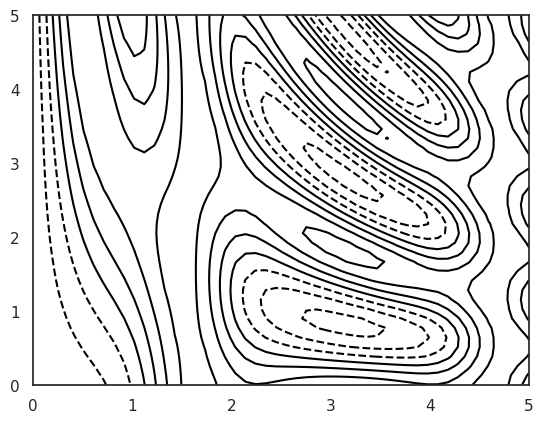

In [ ]:
plt.contour(X, Y, Z, colors='black');

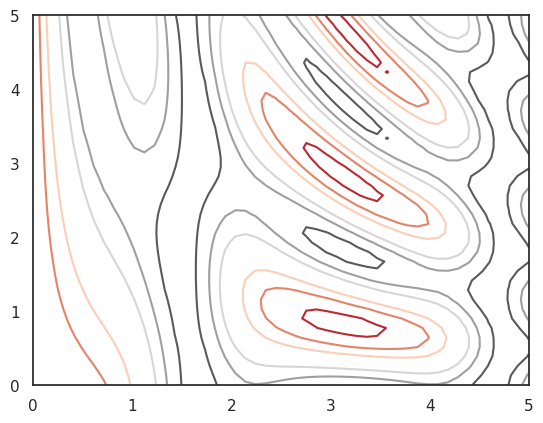

In [ ]:
plt.contour(X, Y, Z, cmap='RdGy');

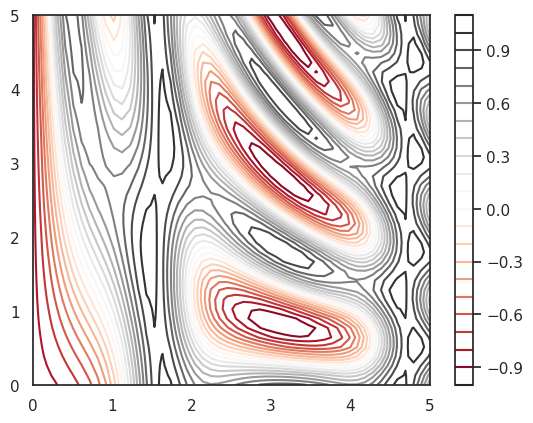

In [ ]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

**Answer Following Questions :**

**1.   Explain what are the changes you observe in contour plots above 3 code cells ?**

**Answer**

colors='black' → All contour lines are black (no color variation).

cmap='RdGy' → Contour lines get different colors based on Z values.

20, cmap='RdGy' → Same colored contours but with 20 levels, so more detailed lines.

plt.colorbar() → Shows color scale to understand Z values.

**2.   What is size of X, Y and Z  respectively ?**

**Answer**

n a contour plot:

X → 2D array of shape (m, n)

Y → 2D array of shape (m, n)

Z → 2D array of shape (m, n)

Important:

All three must have the same dimensions for plt.contour() to work.

So, the size of X, Y, and Z is the same (e.g., 50×50, 100×100, etc., depending on how the grid was created).

**3.   How does colorbar() method help in contour plot.**

**Answer**

plt.colorbar() adds a color scale beside the contour plot.

How it helps:

Shows which color corresponds to which Z value.

Makes it easy to understand data magnitude.

Improves interpretation of colored contour levels.

Without colorbar(), you see colors but don’t know their exact values.

### Creating Smoother Contour Plots
One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level.
A better way to handle this is to use the ``plt.imshow()`` function, which interprets a two-dimensional grid of data as an image.

The following code shows how to perform this:

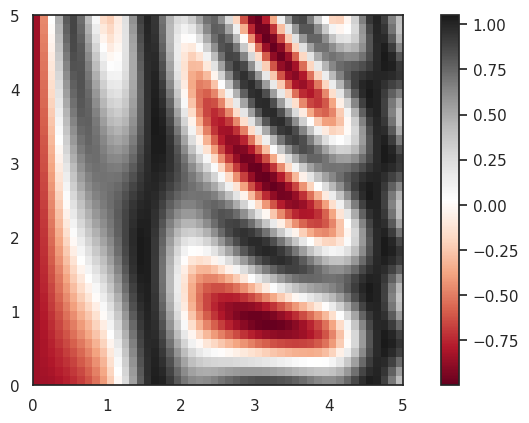

In [ ]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
plt.axis('image');

Things to remember while using ``imshow()``:

- ``plt.imshow()`` doesn't accept an *x* and *y* grid, so you must manually specify the *extent* [*xmin*, *xmax*, *ymin*, *ymax*] of the image on the plot.
- ``plt.imshow()`` by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.
- ``plt.imshow()`` will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, ``plt.axis(aspect='image')`` to make *x* and *y* units match.

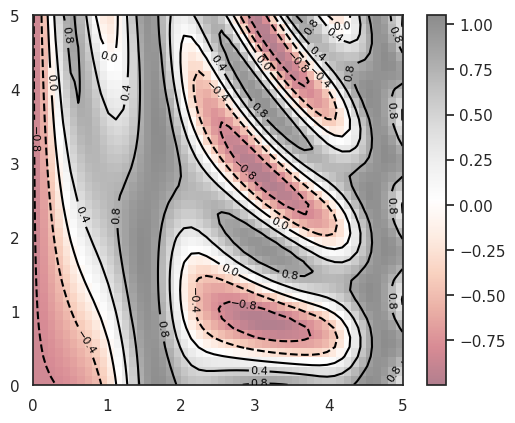

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

**Answer Following Questions :**

**1. What does alpha parameter do ?**

**Answer**

**Adjusts Visibility:** It makes plots or individual elements appear "softer" or more see-through, which is especially useful when overlaying multiple datasets.

**Handles Overlapping Data:** In cases like scatter plots with many overlapping points or layered histograms, setting an alpha value less than 1 allows users to better visualize data density and underlying elements that would otherwise be obscured.

**Supported Elements:** The alpha parameter is supported by almost all plotting functions, including plot(), scatter(), bar(), hist(), fill_between(), and others.

**Blending:** Transparency works by blending the color of the plotted element with the background color or the color of any elements behind it, using a specific formula where higher alpha values give more dominance to the element's color.

**2. What does clabel method does ?**

**Answer :**

**Purpose:** Labels contours in a ContourSet` (CS) or matrix.

**Automatic vs. Manual:** Automatically places labels throughout the plot, or uses manual mode for interactive placement via mouse clicks.

**Customization:** Allows formatting of labels (e.g., using fmt="%2.1f") and adjusting label colors and sizes.

**Functionality:** In MATLAB/Octaveclabel(C,h) can directly label a contour plot object.

**3. Recreate above code block after, changing parameter 4 in contour fuction to 5 from 3. Explain what change you see in the plot.**

**Answer**

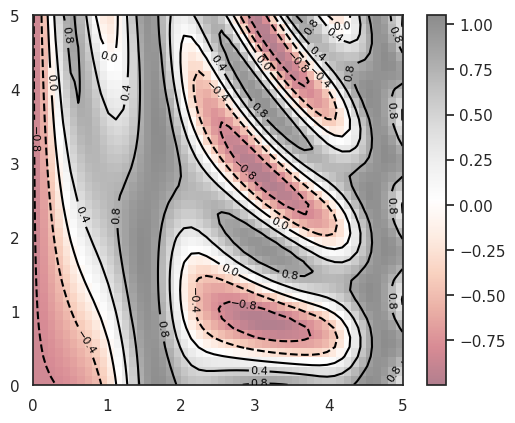

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

### Histogram, Binning Plots

A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:



*   The data should be numerical.
*   A histogram is used to check the shape of the data distribution.
*   Used to check whether the process changes from one period to another.
*   Used to determine whether the output is different when it involves two or more processes.
*   Used to analyse whether the given process meets the customer requirements.



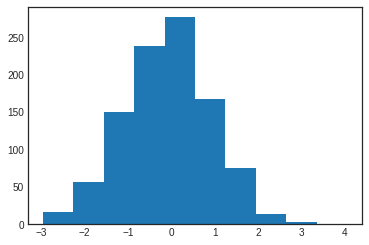

In [ ]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);

The ``hist()`` function has many options to tune both the calculation and the display;
here's an example of a more customized histogram:

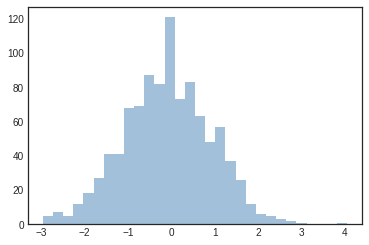

In [ ]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The ``plt.hist`` docstring has more information on other customization options available.
I find this combination of ``histtype='stepfilled'`` along with some transparency ``alpha`` to be very useful when comparing histograms of several distributions:

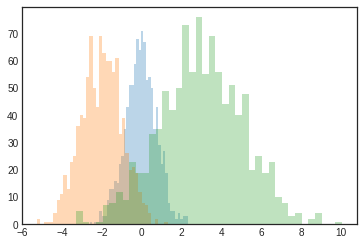

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the ``np.histogram()`` function is available:

In [ ]:
#Only storing histogram bin frequencies without ploting it
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 74 388 445  89   4] [-2.96392645 -1.56020133 -0.1564762   1.24724892  2.65097405  4.05469917]


### ``plt.hist2d``: Two-dimensional histogram

One straightforward way to plot a two-dimensional histogram is to use Matplotlib's ``plt.hist2d`` function:

In [ ]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

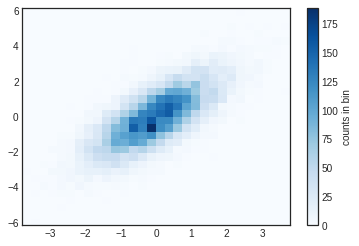

In [ ]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with ``plt.hist``, ``plt.hist2d`` has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring.
Further, just as ``plt.hist`` has a counterpart in ``np.histogram``, ``plt.hist2d`` has a counterpart in ``np.histogram2d``, which can be used as follows:

In [ ]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

### ``plt.hexbin``: Hexagonal binnings

The two-dimensional histogram creates a tesselation of squares across the axes.
Another natural shape for such a tesselation is the regular hexagon.
For this purpose, Matplotlib provides the ``plt.hexbin`` routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

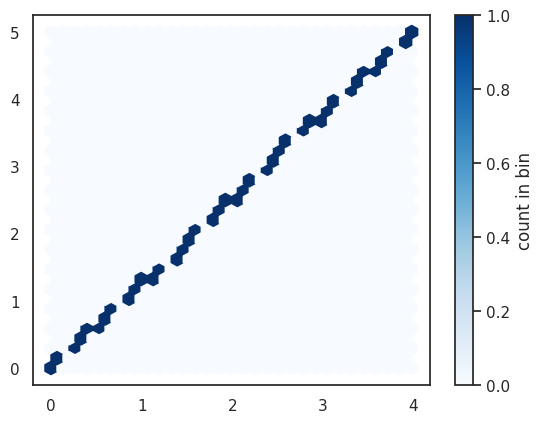

In [ ]:
min_len = min(len(x), len(y))
x = x[:min_len]
y = y[:min_len]

plt.hexbin(x, y, gridsize=30, cmap='Blues')
plt.colorbar(label='count in bin')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Questions:**

**1.  What is role of bins parameter in histogram plot?**

**Answer :**

The bins parameter in a histogram determines how the data is divided into intervals before counting frequencies.

It controls the number of bars in the histogram.

More bins → more detail, narrower bars (may look noisy).

Fewer bins → less detail, wider bars (may hide patterns).

It can be:

A number (e.g., bins=10)

A list of interval boundaries

An automatic method like 'auto'

In short: bins decides how finely your data is grouped in the histogram

**2.  Create a set of 10000 uniform random samples and store it in variable named *norm_data*. Draw histograms of *norm_data* with following bin counts 5, 50, 500, 5000.**

**Answer**

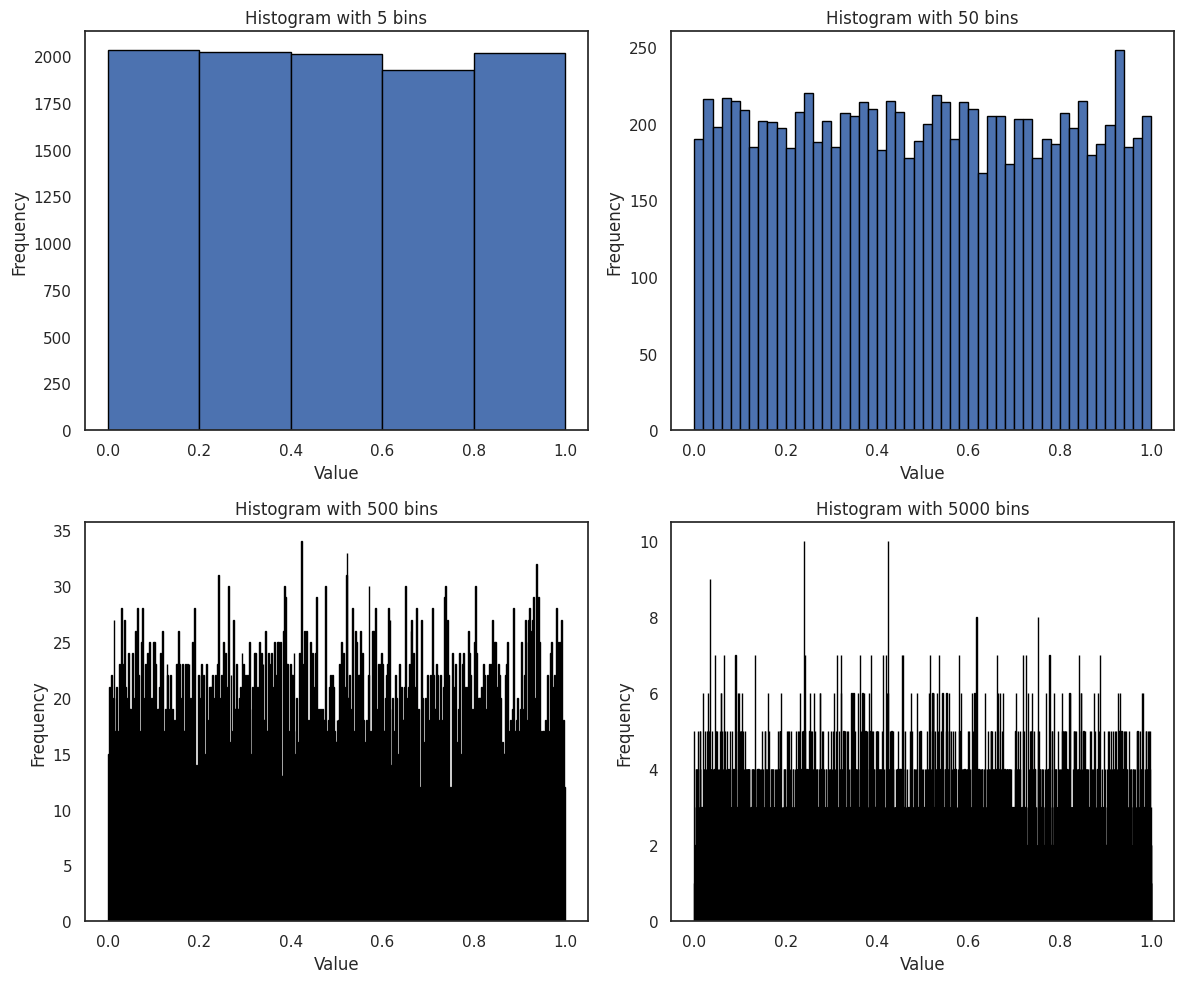

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 10,000 uniform random samples between 0 and 1
norm_data = np.random.uniform(0, 1, 10000)

# Bin counts to use
bin_counts = [5, 50, 500, 5000]

# Create histograms
plt.figure(figsize=(12, 10))

for i, bins in enumerate(bin_counts, 1):
    plt.subplot(2, 2, i)
    plt.hist(norm_data, bins=bins, edgecolor='black')
    plt.title(f'Histogram with {bins} bins')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**3.Explain your observations in text box of above step**

**Answer :**

5 bins: Very smooth and flat; gives coarse overview of uniformity.

50 bins: Still roughly flat; small random variations visible.

500 bins: Spikier; individual bin fluctuations show due to fewer points per bin.

5000 bins: Very noisy; most bins have very few points, histogram looks irregular

### Ploting from a CSV File

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:14: MatplotlibDeprecationWarning: Passing unsupported keyword arguments to axis() will raise a TypeError in 3.3.
  


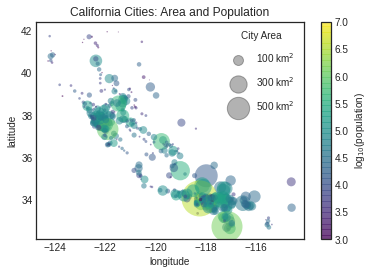

In [ ]:
# Path to file /content/california_cities.csv

import pandas as pd
cities = pd.read_csv('/content/drive/MyDrive/AIDS1 /notebooks/data/california_cities.csv')

# Extract the data we're interested in
lat, lon = cities['latd'], cities['longd']
population, area = cities['population_total'], cities['area_total_km2']

# Scatter the points, using size and color but no label
plt.scatter(lon, lat, label=None,
            c=np.log10(population), cmap='viridis',
            s=area, linewidth=0, alpha=0.5)
plt.axis(aspect='equal')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar(label='log$_{10}$(population)')
plt.clim(3, 7)

# Here we create a legend:
# we'll plot empty lists with the desired size and label
for area in [100, 300, 500]:
    plt.scatter([], [], c='k', alpha=0.3, s=area,
                label=str(area) + ' km$^2$')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title='City Area')

plt.title('California Cities: Area and Population');

### Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of *subplots* : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.

In [ ]:
import seaborn as sns
sns.set_theme(style="white")
import numpy as np

### ``plt.axes``: Subplots by Hand (Coding)

The most basic method of creating an axes is to use the ``plt.axes`` function. By default this creates a standard axes object that fills the entire figure.

``plt.axes`` also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent
``[left, bottom, width, height]`` in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the *x* and *y* position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the *x* and *y* extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

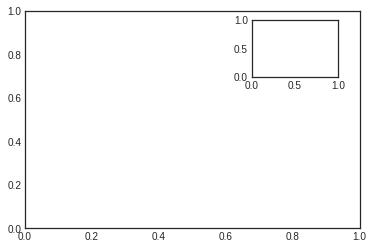

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

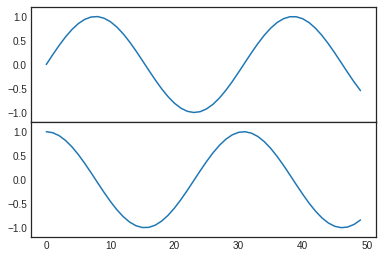

In [ ]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

### ``plt.subplot``: Simple Grids of Subplots

Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is ``plt.subplot()``, which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

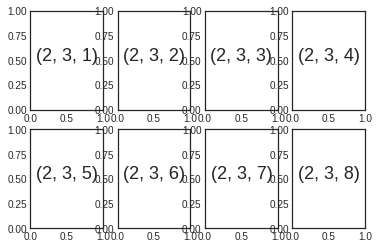

In [ ]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')


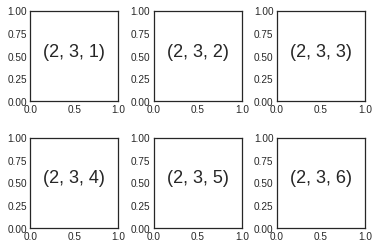

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

### ``plt.subplots``: The Whole Grid in One Go

The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots.
For this purpose, ``plt.subplots()`` is the easier tool to use (note the ``s`` at the end of ``subplots``). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array.
The arguments are the number of rows and number of columns, along with optional keywords ``sharex`` and ``sharey``, which allow you to specify the relationships between different axes.

Here we'll create a $2 \times 3$ grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

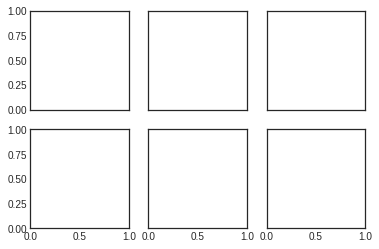

In [ ]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying ``sharex`` and ``sharey``, we've automatically removed inner labels on the grid to make the plot cleaner.


The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

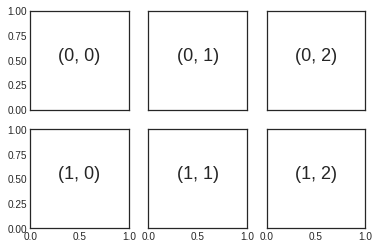

In [ ]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

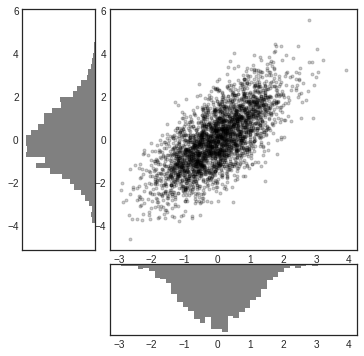

In [ ]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()


In [ ]:
import matplotlib as mpl
# An example of Complex Plotting
births = pd.read_csv('/content/drive/MyDrive/AIDS1 /notebooks/data/births.csv')

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(10000 * births.year +
                              100 * births.month +
                              births.day, format='%Y%m%d')
births_by_date = births.pivot_table('births',
                                    [births.index.month, births.index.day])
births_by_date.index = [pd.datetime(2012, month, day)
                        for (month, day) in births_by_date.index]

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:17: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.


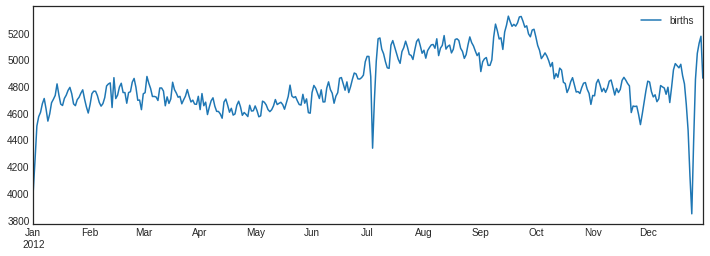

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);

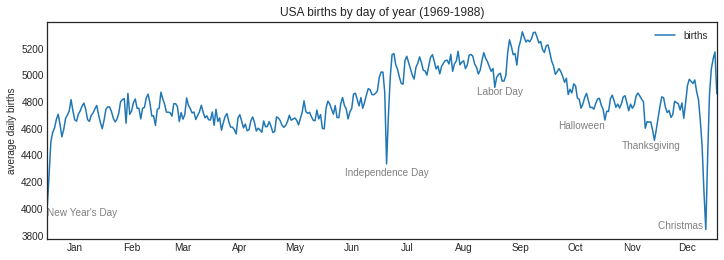

### Boxplot

A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.



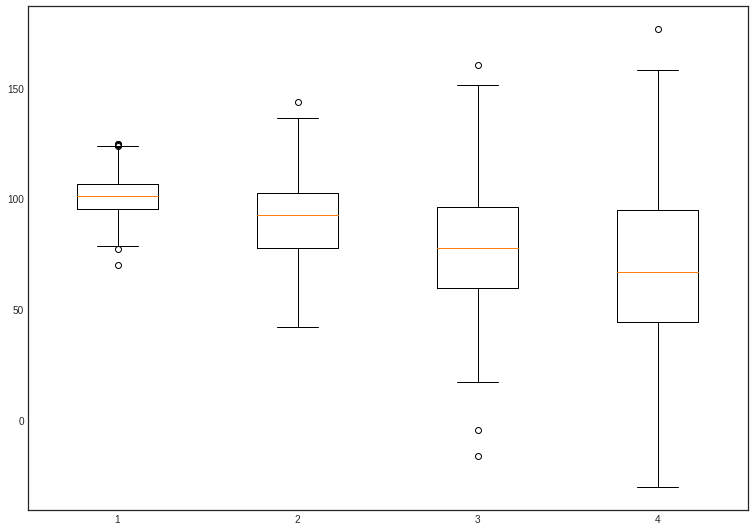

In [ ]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()


**Questions:**

**1. What is boxplot ?**

**Answer :**

Boxplot in Matplotlib :

In Matplotlib, a boxplot is created using plt.boxplot(data).

It shows minimum value.

It shows first quartile (Q1).

It shows median (Q2).

It shows third quartile (Q3).

It shows maximum value.

It displays outliers as separate points.

It helps to understand data distribution and spread

**2.What information do we get from a box plot?**

**Answer:**

Information we get from a Box Plot:

Shows the minimum value.

Shows the maximum value.

Shows the median (middle value).

Shows first quartile (Q1).

Shows third quartile (Q3).

Shows the interquartile range (IQR).

Identifies outliers.

Shows the spread and distribution of data.

**3.How is minimum and maximum whisker's marked in a box plot ?**

**Answer :**

The whiskers are thin vertical lines extending from the box.

The lower whisker starts from Q1 and goes down to the smallest non-outlier value.

The upper whisker starts from Q3 and goes up to the largest non-outlier value.

The ends of whiskers are marked with small horizontal caps (lines).

If there are no outliers, whiskers reach the actual minimum and maximum values.

If outliers exist, whiskers stop at 1.5 × IQR limit.

Values beyond this limit are shown as separate dots or circles.

The whiskers help show the range and spread of the data.

**4.How to we identify that some points in data are outliers by viewing the box plot**

**Answer :**

Outliers are shown as separate dots, circles, or small symbols.

They appear outside the whiskers of the box plot.

The whiskers usually extend up to 1.5 × IQR from Q1 and Q3.

Any value less than (Q1 − 1.5 × IQR) is a lower outlier.

Any value greater than (Q3 + 1.5 × IQR) is an upper outlier.

Outliers are visually distant from the main box.

If many outliers appear on one side, the data may be skewed.

Extreme outliers may be much farther from the whiskers than regular outliers.

**5. Read a data file from your drive and for all numeric columns plot boxplot.**

**Answer :**

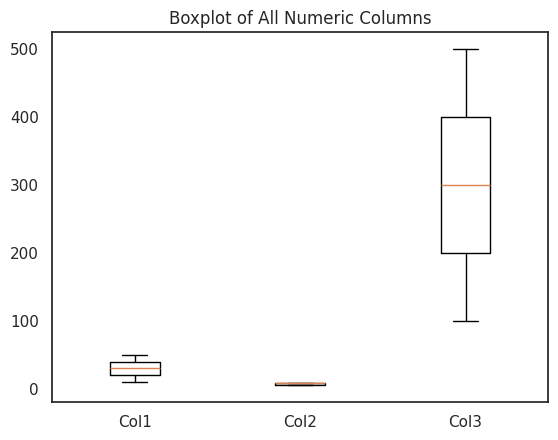

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file
df = pd.read_csv("numeric_values.csv")

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plot boxplot
plt.boxplot(numeric_df.values)
plt.xticks(range(1, len(numeric_df.columns) + 1), numeric_df.columns)
plt.title("Boxplot of All Numeric Columns")
plt.show()

**Conclusion**

Thus we have learned about basics of Contour plots, Histograms, Box plots.